# Análise de dados - Inferência Estatística

O objetivo desta atividade é re-utilizar os dados de uma avaliação educacional federal e fazer algumas inferências sobre como as variáveis de estudo se comportam


O objetivo desta atividade é levantar alguma hipóteses sobre os dados e sugestões de intervenções. 
No campo de políticas públicas, é sempre importante que as decisões sejam baseadas em dados (e não em achismos). Assim é importante saber:
-  O 6º ano e o 8º ano não reprovam, logo rend_6 e rend_8 devem estar o mais próximo possível de 1,0 (100%);
-  O As médias das notas de Língua Portuguesa e Matemática quanto maior melhor; 
- Existe uma fórmula matemática que relaciona o Indicador de Rendimento, a Nota Padronizada e o IDEB;
- Os governos federal e distrital utilizam-se do IDEB para distribuir dinheiro para as escolas;
- No ano de 2021, que são as referências para estes dados, não houve reprovação por conta da pandemia de Covid 19.

Assim, utilizando novamente os dados de SAEB, vocês devem:
1) Analise a presença de outliers no redimento (aprovação) de cada um dos anos e das notas de Língua Portuguesa, Matemática e IDEB (faça o boxplot de cada uma dessas variáveis). Os dados estão bem distribuídos (utilize as técnicas que acharem mais viáveis para fazer esta análise);
2) Calcule a covariância das seguintes variáveis (variância conjunta): aprovação média e indicador de rendimento, indicador de rendimento e nota padronizada, nota padronizada e IDEB, indicador de rendimento e IDEB.
3) Faça gráficos de dispersão das informações acima. É possível identificar algum padrão?
4) Calcule a correlação dos itens pedidos em (2). Explique os resultados obtidos, partindo da definição de correlação. 
5) Calcule o índice chamado R quadrado para os itens calculados em (4). Qual o significado dos resultados obtidos?
6) Há algum relação entre os resultados obtidos nos itens  (2) e (4).
7) O que é possível inferir de todas as análises realizadas nos itens de (1) a (4).

## QUESTÃO 1

Analise a presença de outliers no redimento (aprovação) de cada um dos anos e das notas de Língua Portuguesa, Matemática e IDEB (faça o boxplot de cada uma dessas variáveis). Os dados estão bem distribuídos (utilize as técnicas que acharem mais viáveis para fazer esta análise);

In [61]:
import pandas as pd
import matplotlib.pyplot as plt


In [62]:
dados = pd.read_csv("DadosIDEB.csv")
dados.head()
dados.describe()

,Cod_Escola,Ap_Media,Rend_6,Rend_7,Rend_8,Rend_9,Indicador_de_rendimento,Nota_SAEB_Mat,Nota_SAEB_LP,Nota_Padronizada,IDEB
count,1.030000e+02,103.000000,100.00000,102.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000
mean,5.300990e+07,95.572816,98.72100,92.477451,97.943689,93.585437,0.954298,254.059709,255.911165,5.166181,4.931068
std,1.156610e+04,3.633698,2.08236,6.942521,3.301475,6.164373,0.038126,10.827693,11.980423,0.366607,0.440594
min,5.300085e+07,83.400000,90.80000,69.000000,81.300000,71.400000,0.825044,226.820000,223.940000,4.263167,3.800000
25%,5.300469e+07,93.750000,98.27500,88.625000,97.000000,90.950000,0.936751,247.195000,246.165000,4.910916,4.600000
50%,5.300792e+07,96.400000,100.00000,94.250000,99.400000,95.500000,0.962210,252.920000,256.160000,5.141167,5.000000
75%,5.301105e+07,98.350000,100.00000,97.850000,100.000000,98.000000,0.983154,261.290000,265.045000,5.446333,5.300000
max,5.306821e+07,100.000000,100.00000,100.000000,100.000000,100.000000,1.000000,279.250000,284.890000,6.069000,5.800000


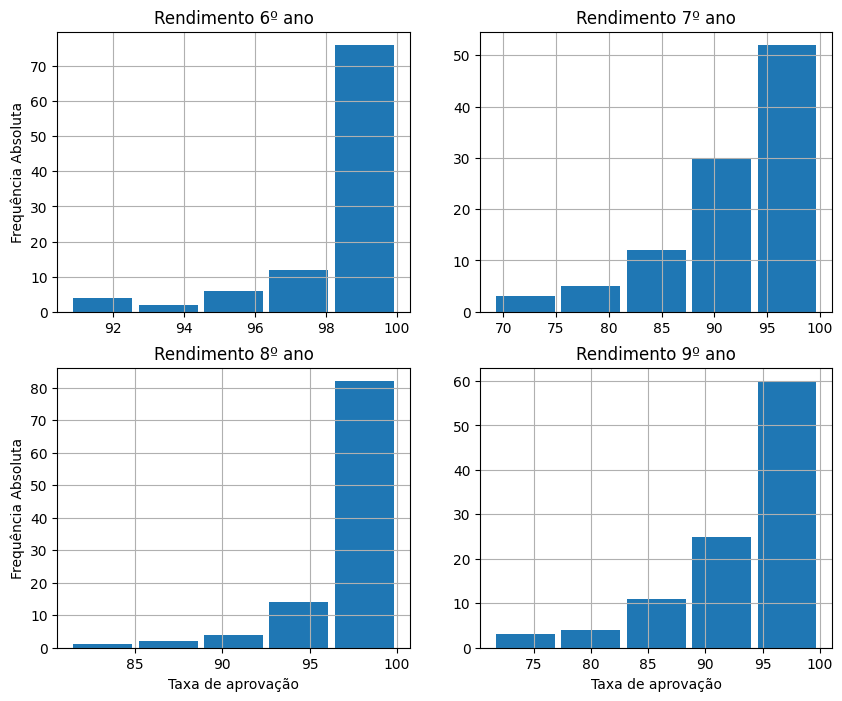

In [63]:
dados = pd.read_csv('DadosIDEB.csv')
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

Rend_6 = dados['Rend_6'].dropna()
Rend_7 = dados['Rend_7'].dropna()
Rend_8 = dados['Rend_8'].dropna()
Rend_9 = dados['Rend_9'].dropna()

# Gráfico para o 6º ano
Rend_6 = dados['Rend_6']
axs[0, 0].hist(Rend_6, bins=5, rwidth=0.9)
axs[0, 0].set_title('Rendimento 6º ano')
axs[0, 0].set_ylabel('Frequência Absoluta')
axs[0, 0].grid(True)

# Gráfico para o 7º ano
Rend_7 = dados['Rend_7']
axs[0, 1].hist(Rend_7, bins=5, rwidth=0.9)
axs[0, 1].set_title('Rendimento 7º ano')
axs[0, 1].grid(True)

# Gráfico para o 8º ano
Rend_8 = dados['Rend_8']
axs[1, 0].hist(Rend_8, bins=5, rwidth=0.9)
axs[1, 0].set_title('Rendimento 8º ano')
axs[1, 0].set_ylabel('Frequência Absoluta')
axs[1, 0].set_xlabel('Taxa de aprovação')
axs[1, 0].grid(True)

# Gráfico para o 9º ano
Rend_9 = dados['Rend_9']
axs[1, 1].hist(Rend_9, bins=5, rwidth=0.9)
axs[1, 1].set_title('Rendimento 9º ano')
axs[1, 1].set_xlabel('Taxa de aprovação')
axs[1, 1].grid(True)

plt.show()


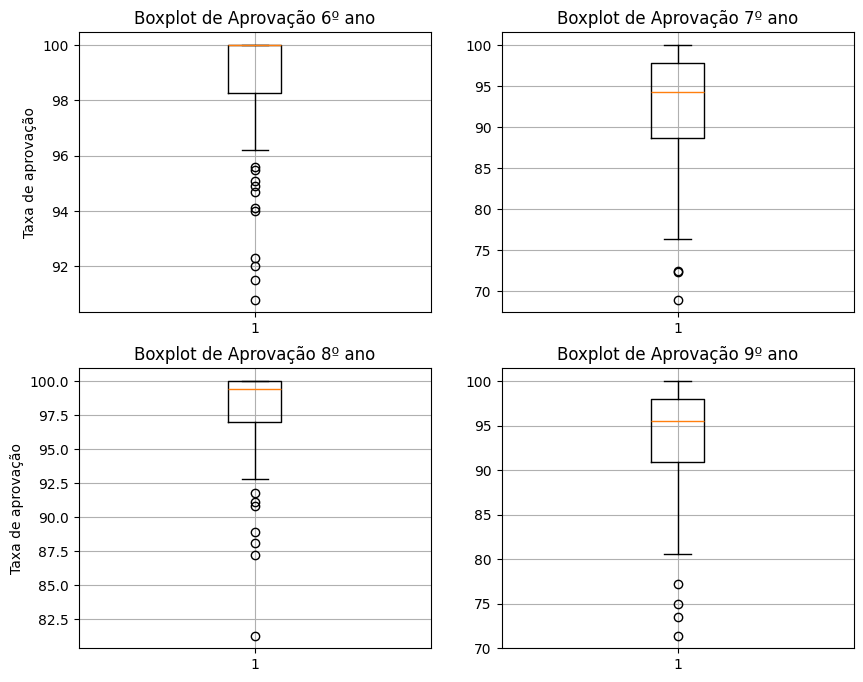

In [64]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

Rend_6 = dados['Rend_6'].dropna()
Rend_7 = dados['Rend_7'].dropna()
Rend_8 = dados['Rend_8'].dropna()
Rend_9 = dados['Rend_9'].dropna()

# Boxplot para o 6º ano
axs[0, 0].boxplot(Rend_6)
axs[0, 0].set_ylabel('Taxa de aprovação')
axs[0, 0].set_title('Boxplot de Aprovação 6º ano')
axs[0, 0].grid(True)

# Boxplot para o 7º ano
axs[0, 1].boxplot(Rend_7)
axs[0, 1].set_title('Boxplot de Aprovação 7º ano')
axs[0, 1].grid(True)

# Boxplot para o 8º ano
axs[1, 0].boxplot(Rend_8)
axs[1, 0].set_ylabel('Taxa de aprovação')
axs[1, 0].set_title('Boxplot de Aprovação 8º ano')
axs[1, 0].grid(True)

# Boxplot para o 9º ano
axs[1, 1].boxplot(Rend_9)
axs[1, 1].set_title('Boxplot de Aprovação 9º ano')
axs[1, 1].grid(True)

plt.show()


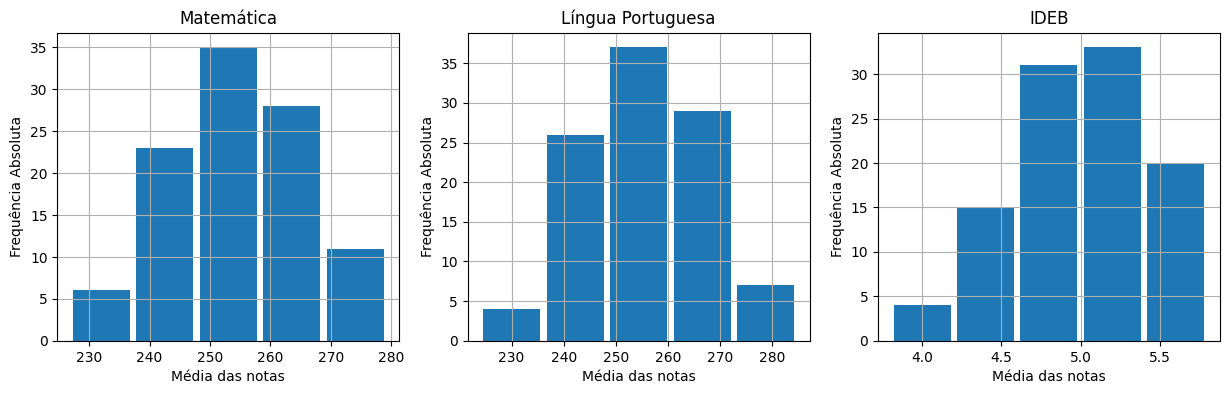

In [65]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# Gráfico para a média de matemática
NotaMat = dados['Nota_SAEB_Mat']
axs[0].hist(NotaMat, bins=5, rwidth=0.9)
axs[0].set_title('Matemática')
axs[0].set_xlabel('Média das notas')
axs[0].set_ylabel('Frequência Absoluta')
axs[0].grid(True)

# Gráfico para a média de português
NotaPt = dados['Nota_SAEB_LP']
axs[1].hist(NotaPt, bins=5, rwidth=0.9)
axs[1].set_title('Língua Portuguesa')
axs[1].set_xlabel('Média das notas')
axs[1].set_ylabel('Frequência Absoluta')
axs[1].grid(True)

# Gráfico para a nota IDEB
NotaIDEB = dados['IDEB']
axs[2].hist(NotaIDEB, bins=5, rwidth=0.9)
axs[2].set_title('IDEB')
axs[2].set_xlabel('Média das notas')
axs[2].set_ylabel('Frequência Absoluta')
axs[2].grid(True)

plt.show()



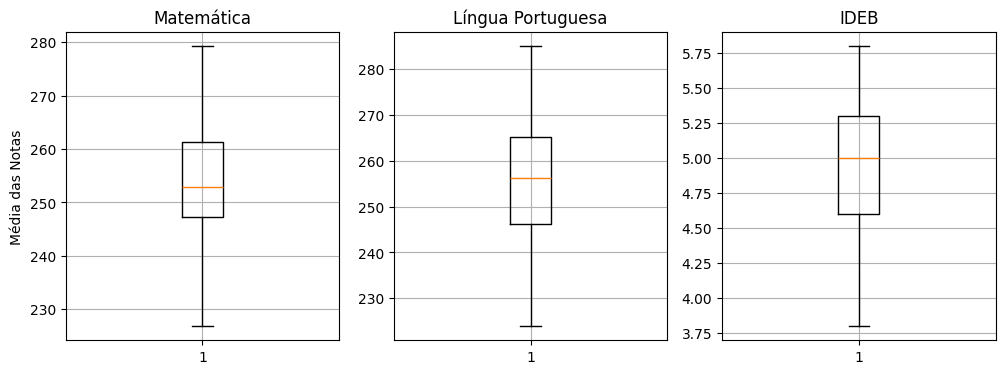

In [66]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

NotaMat = dados['Nota_SAEB_Mat'].dropna()
NotaPt = dados['Nota_SAEB_LP'].dropna()
NotaIDEB = dados['IDEB'].dropna()

# Boxplot para o 6º ano
axs[0].boxplot(NotaMat)
axs[0].set_ylabel('Média das Notas')
axs[0].set_title('Matemática')
axs[0].grid(True)

# Boxplot para o 7º ano
axs[1].boxplot(NotaPt)
axs[1].set_title('Língua Portuguesa')
axs[1].grid(True)

# Boxplot para o 8º ano
axs[2].boxplot(NotaIDEB)
axs[2].set_title('IDEB')
axs[2].grid(True)

plt.show()


É possível perceber presença de outliers nos boxplot referêntes a aprovação. Para os anos que não reprovam a presença de outliers pode remeter ao abandono escolar.
Analisando os gráficos e boxplots de média de nota em matemática, língua portuguesa e do IDEB podemos ver que eles não apresentam outliers e apresentam algo próximo a função, o que pode indiciar ainda mais que os outliers presentes nos gráficos de rendimento se devem principalmente ao abandono escolar.

## QUESTÃO 2

Calcule a covariância das seguintes variáveis (variância conjunta): aprovação média e indicador de rendimento, indicador de rendimento e nota padronizada, nota padronizada e IDEB, indicador de rendimento e IDEB.

In [67]:
dados.columns

Index(['UF', 'Municipio', 'Cod_Escola', 'Rede', 'Ap_Media', 'Rend_6', 'Rend_7',
       'Rend_8', 'Rend_9', 'Indicador_de_rendimento', 'Nota_SAEB_Mat',
       'Nota_SAEB_LP', 'Nota_Padronizada', 'IDEB'],
      dtype='object')

In [68]:
# Calcular a covariância entre aprovação média e indicador de rendimento
cov1 = dados[['Ap_Media', 'Indicador_de_rendimento']].cov().iloc[0, 1]

# Calcular a covariância entre indicador de rendimento e nota padronizada
cov2 = dados[['Indicador_de_rendimento', 'Nota_Padronizada']].cov().iloc[0, 1]

# Calcular a covariância entre nota padronizada e IDEB
cov3 = dados[['Nota_Padronizada', 'IDEB']].cov().iloc[0, 1]

# Calcular a covariância entre indicador de rendimento e IDEB
cov4 = dados[['Indicador_de_rendimento', 'IDEB']].cov().iloc[0, 1]

# Exibir os resultados
print(f"Covariância entre Aprovação Média e Indicador de Rendimento: {cov1}")
print(f"Covariância entre Indicador de Rendimento e Nota Padronizada: {cov2}")
print(f"Covariância entre Nota Padronizada e IDEB: {cov3}")
print(f"Covariância entre Indicador de Rendimento e IDEB: {cov4}")


Covariância entre Aprovação Média e Indicador de Rendimento: 0.1355854884066247
Covariância entre Indicador de Rendimento e Nota Padronizada: 0.0036108402184922878
Covariância entre Nota Padronizada e IDEB: 0.14466523417094992
Covariância entre Indicador de Rendimento e IDEB: 0.011009083837806972


## QUESTÃO 3

Faça gráficos de dispersão das informações acima. É possível identificar algum padrão?

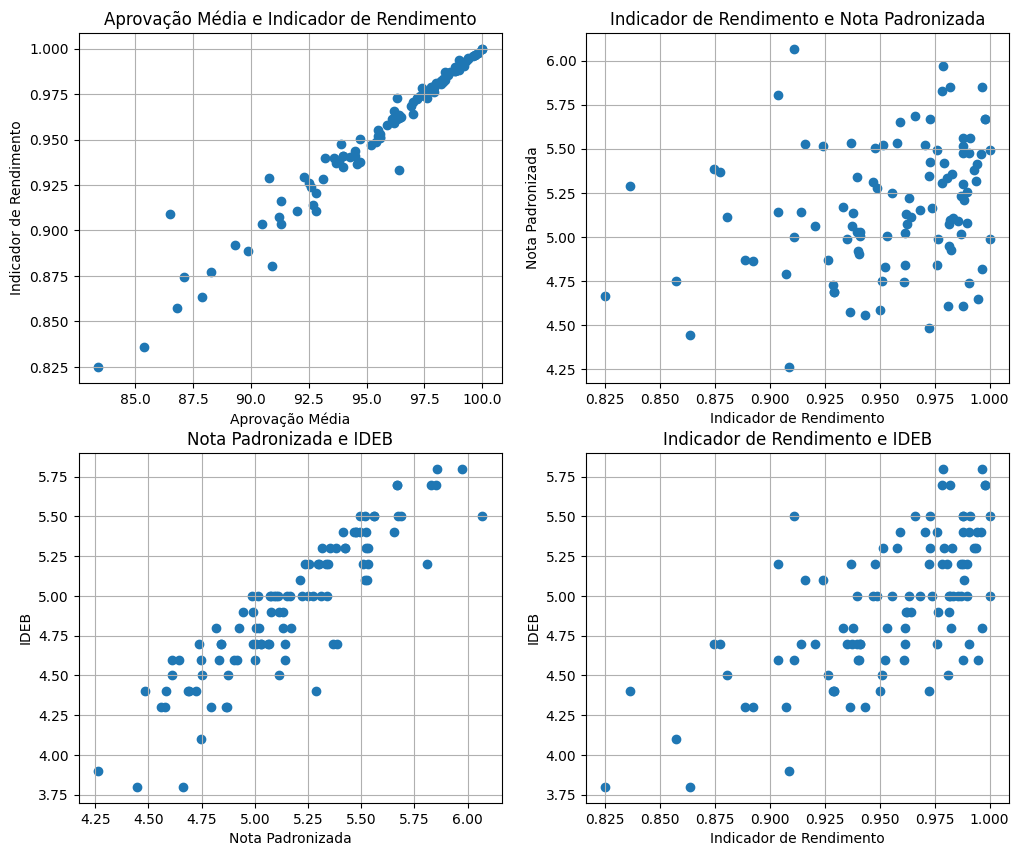

In [69]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Aprovação média e indicador de rendimento
axs[0, 0].scatter(dados['Ap_Media'], dados['Indicador_de_rendimento'])
axs[0, 0].set_xlabel('Aprovação Média')
axs[0, 0].set_ylabel('Indicador de Rendimento')
axs[0, 0].set_title('Aprovação Média e Indicador de Rendimento')
axs[0, 0].grid(True)

# Indicador de rendimento e nota padronizada
axs[0, 1].scatter(dados['Indicador_de_rendimento'], dados['Nota_Padronizada'])
axs[0, 1].set_xlabel('Indicador de Rendimento')
axs[0, 1].set_ylabel('Nota Padronizada')
axs[0, 1].set_title('Indicador de Rendimento e Nota Padronizada')
axs[0, 1].grid(True)

# Nota padronizada e IDEB
axs[1, 0].scatter(dados['Nota_Padronizada'], dados['IDEB'])
axs[1, 0].set_xlabel('Nota Padronizada')
axs[1, 0].set_ylabel('IDEB')
axs[1, 0].set_title('Nota Padronizada e IDEB')
axs[1, 0].grid(True)

# Indicador de rendimento e IDEB
axs[1, 1].scatter(dados['Indicador_de_rendimento'], dados['IDEB'])
axs[1, 1].set_xlabel('Indicador de Rendimento')
axs[1, 1].set_ylabel('IDEB')
axs[1, 1].set_title('Indicador de Rendimento e IDEB')
axs[1, 1].grid(True)

plt.show()

É possível notar que as covariâncias apresentam um gráfico crescente, é possível perceber um sinal de crescimento em todos os gráficos, porém é muito mais perceptível nos gráficos 1 e 3.

## QUESTÃO 4

Calcule a correlação dos itens pedidos em (2). Explique os resultados obtidos, partindo da definição de correlação

In [70]:
corr1 = dados[['Ap_Media', 'Indicador_de_rendimento']].corr().iloc[0, 1]

corr2 = dados[['Indicador_de_rendimento', 'Nota_Padronizada']].corr().iloc[0, 1]

corr3 = dados[['Nota_Padronizada', 'IDEB']].corr().iloc[0, 1]

corr4 = dados[['Indicador_de_rendimento', 'IDEB']].corr().iloc[0, 1]

# Exibir os resultados
print(f"Correlação entre Aprovação Média e Indicador de Rendimento: {corr1}")
print(f"Correlação entre Indicador de Rendimento e Nota Padronizada: {corr2}")
print(f"Correlação entre Nota Padronizada e IDEB: {corr3}")
print(f"Correlação entre Indicador de Rendimento e IDEB: {corr4}")


Correlação entre Aprovação Média e Indicador de Rendimento: 0.9786902639919046
Correlação entre Indicador de Rendimento e Nota Padronizada: 0.25833801161150405
Correlação entre Nota Padronizada e IDEB: 0.8956212524543081
Correlação entre Indicador de Rendimento e IDEB: 0.655380037504145


1) Aprovação Média e Indicador de Rendimento

Apresenta uma correlação positiva

2) Indicador de Rendimento e Nota Padronizada

Baixa correlação positiva

3) Nota Padronizada e IDEB

Apresenta uma correlação positiva

4) Indicador de Rendimento e IDEB

Os pontos estão muito dispersos porém nota-se que apresentam uma correlação positiva

---------------------------------------------------------------------------------------------------------------------
Essa correlação positiva representa que os dados são diretamente proporcionais, o que significa que caso uma delas diminua a outra tende a diminuir também, porém no gráfico 2 e 4 não é possível ver isso tão claramente o que significa que uma variável não depende tanto da outra.

## QUESTÃO 5

Calcule o índice chamado R quadrado para os itens calculados em (4). Qual o significado dos resultados obtidos?

In [71]:
# Calcular R²
r2_1 = corr1**2
r2_2 = corr2**2
r2_3 = corr3**2
r2_4 = corr4**2

# Exibir os resultados
print(f"R² entre Aprovação Média e Indicador de Rendimento: {r2_1}")
print(f"R² entre Indicador de Rendimento e Nota Padronizada: {r2_2}")
print(f"R² entre Nota Padronizada e IDEB: {r2_3}")
print(f"R² entre Indicador de Rendimento e IDEB: {r2_4}")


R² entre Aprovação Média e Indicador de Rendimento: 0.957834632832544
R² entre Indicador de Rendimento e Nota Padronizada: 0.0667385282433856
R² entre Nota Padronizada e IDEB: 0.8021374278478235
R² entre Indicador de Rendimento e IDEB: 0.4295229935589345


1) indica uma relação muito forte e um bom ajuste ao modelo linear.
2) sugere uma relação fraca, indicando que a nota padronizada não é um bom preditor do indicador de rendimento.
3) indica uma relação forte e um bom ajuste ao modelo linear.
4) Isso sugere uma relação moderada, indicando que o IDEB é um preditor razoável do indicador de rendimento.

## QUESTÃO 6

Há algum relação entre os resultados obtidos nos itens  (2) e (4).

Ambos os conceitos estão relacionados à medida de relação entre duas variáveis.

1) A covariância mede a relação linear entre duas variáveis em termos de como elas variam juntas.

2) A correlação é uma versão padronizada da covariância, normalizada em uma escala de -1 a 1. Ela indica não apenas a direção da relação linear entre duas variáveis, mas também a força dessa relação.

## QUESTÃO 7

O que é possível inferir de todas as análises realizadas nos itens de (1) a (4).

O rendimento, que apresenta uma forte correlação com a aprovação, não parece ser tão influenciado pela nota média das turmas. Isso sugere que fatores o desempenho dos alunos não é a causa das aprovações.